In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")



Libraries imported successfully


In [9]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [13]:
df = pd.read_csv("/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.shape

(9994, 21)

In [15]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [18]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date columns converted successfully!")

Date columns converted successfully!


In [21]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [22]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [23]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [24]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


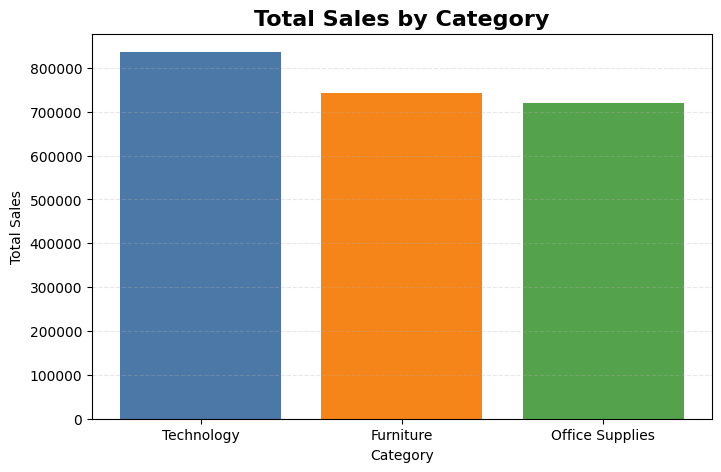

In [27]:
plt.figure(figsize=(8, 5))

colors = ['#4C78A8', '#F58518', '#54A24B']

plt.bar(
    category_sales.index,
    category_sales.values,
    color=colors
)

plt.title("Total Sales by Category", fontsize=16, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [28]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


/tmp/ipykernel_1848/3580269508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


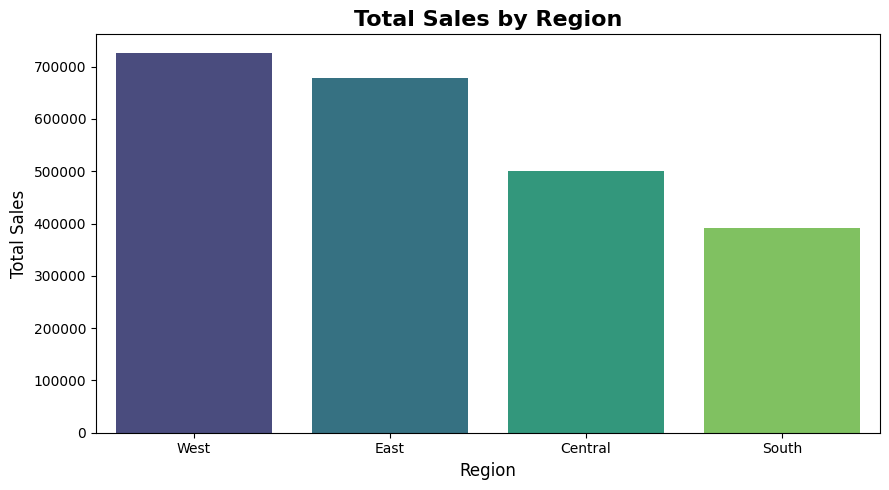

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

,Sales
Order Date,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


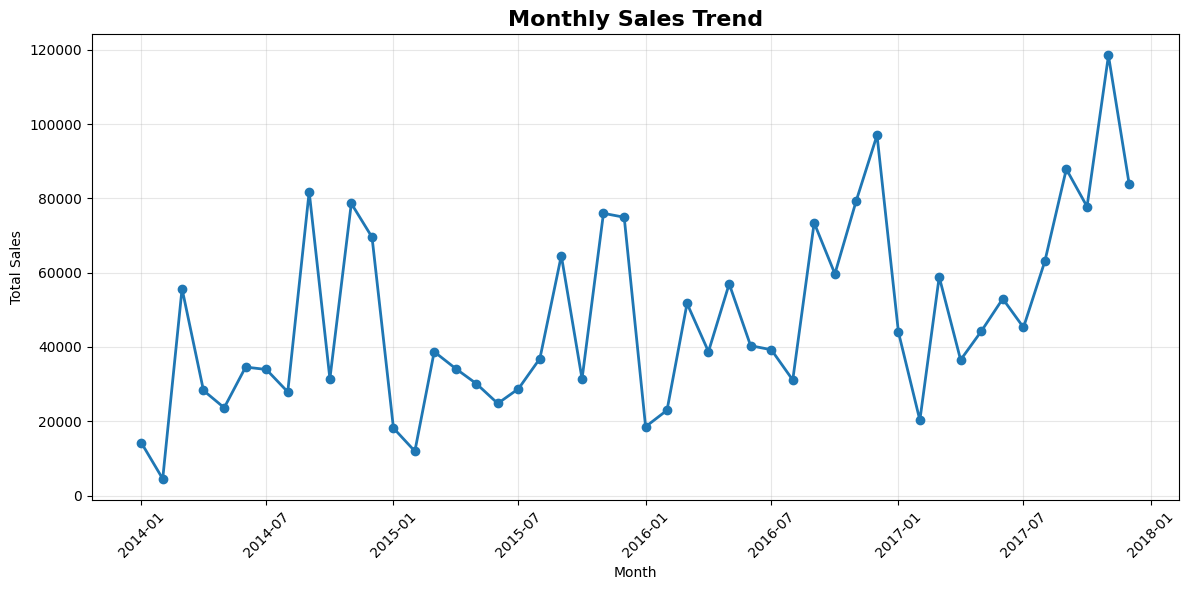

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [32]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


/tmp/ipykernel_1848/2417844424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


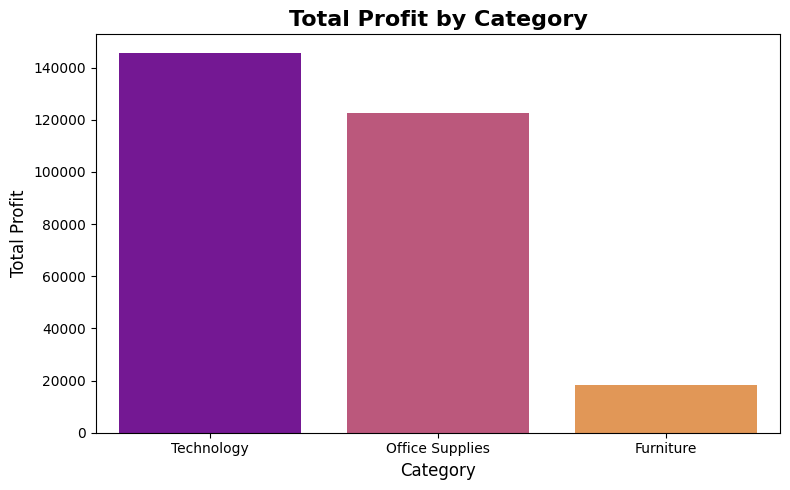

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    palette="plasma"
)

plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


/tmp/ipykernel_1848/921657253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


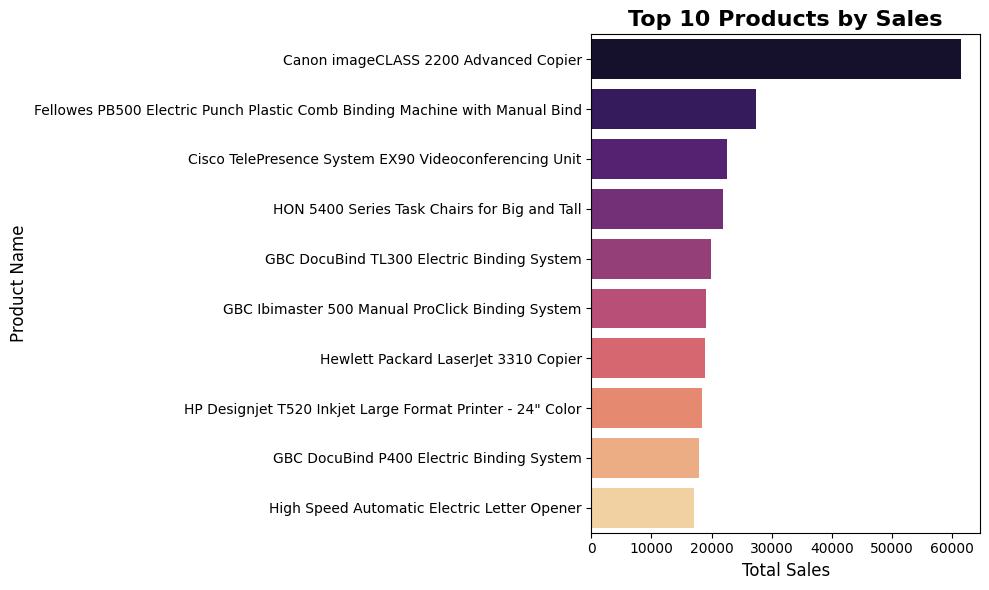

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="magma"
)

plt.title("Top 10 Products by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.tight_layout()
plt.show()

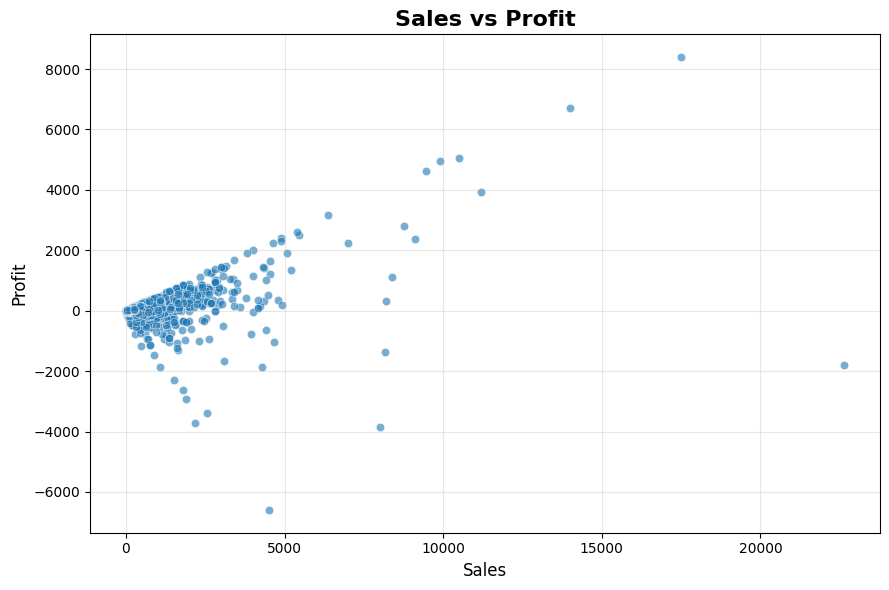

In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    alpha=0.6
)

plt.title("Sales vs Profit", fontsize=16, fontweight="bold")
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

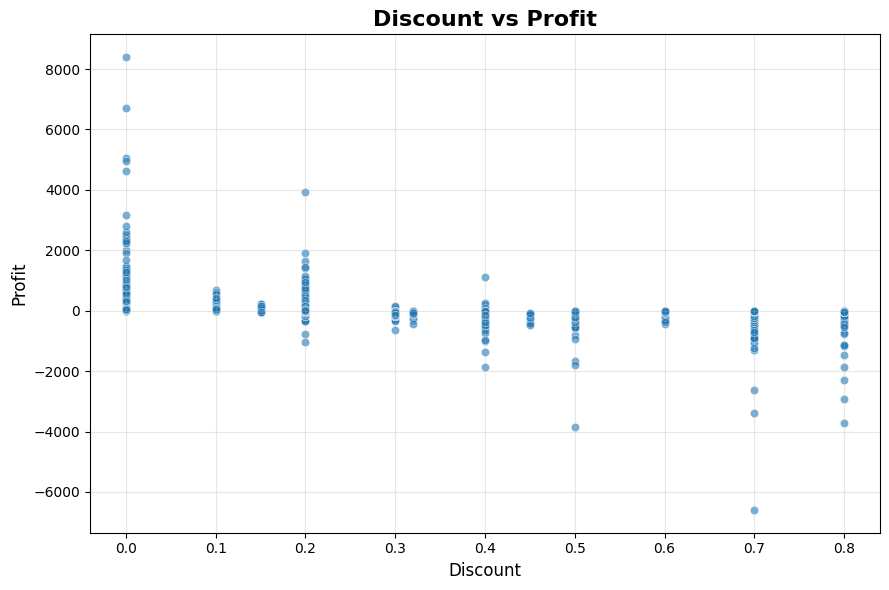

In [37]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title("Discount vs Profit", fontsize=16, fontweight="bold")
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_orders = df['Order ID'].nunique()
average_sales = df['Sales'].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Average Sales per Record:", round(average_sales, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Total Orders: 5009
Average Sales per Record: 229.86


In [39]:
profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


In [40]:
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum()

category_performance.sort_values('Profit', ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


In [41]:
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum()

region_performance.sort_values('Profit', ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [42]:
top_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_profit_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


In [43]:
summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Quantity',
        'Total Orders',
        'Average Sales',
        'Profit Margin'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_quantity,
        total_orders,
        average_sales,
        profit_margin
    ]
})

summary

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Quantity,3.787300e+04
3,Total Orders,5.009000e+03
4,Average Sales,2.298580e+02
5,Profit Margin,1.246722e+01


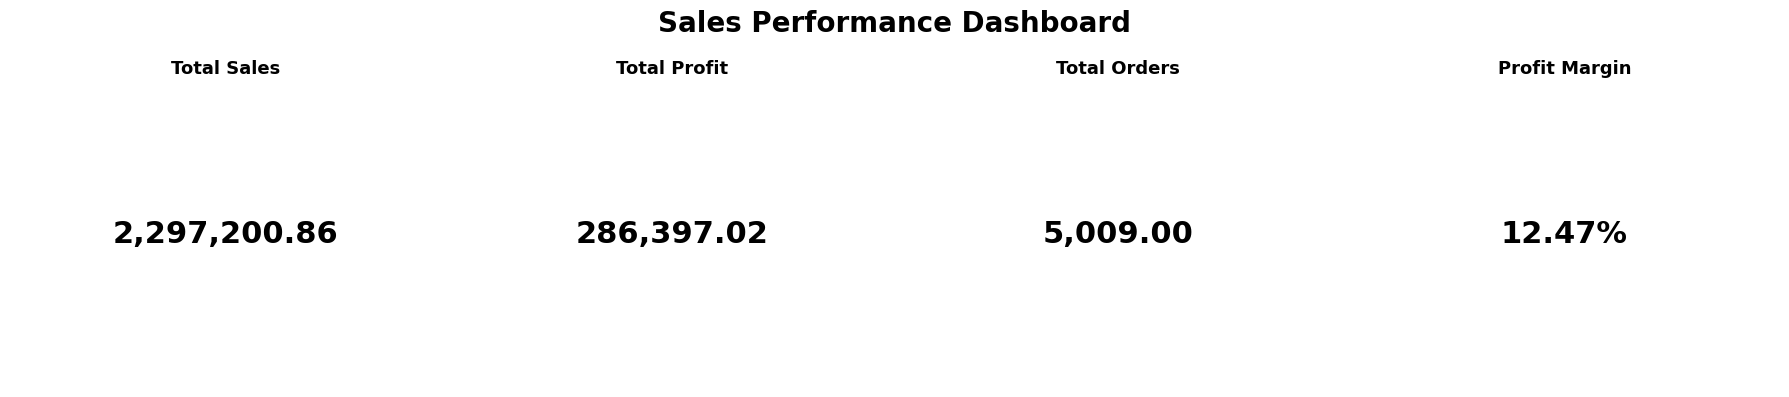

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

kpis = [
    ("Total Sales", total_sales),
    ("Total Profit", total_profit),
    ("Total Orders", total_orders),
    ("Profit Margin", profit_margin)
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.5,
        f"{value:,.2f}" if title != "Profit Margin" else f"{value:.2f}%",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle(
    "Sales Performance Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1848/3661194252.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1848/3661194252.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1848/3661194252.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


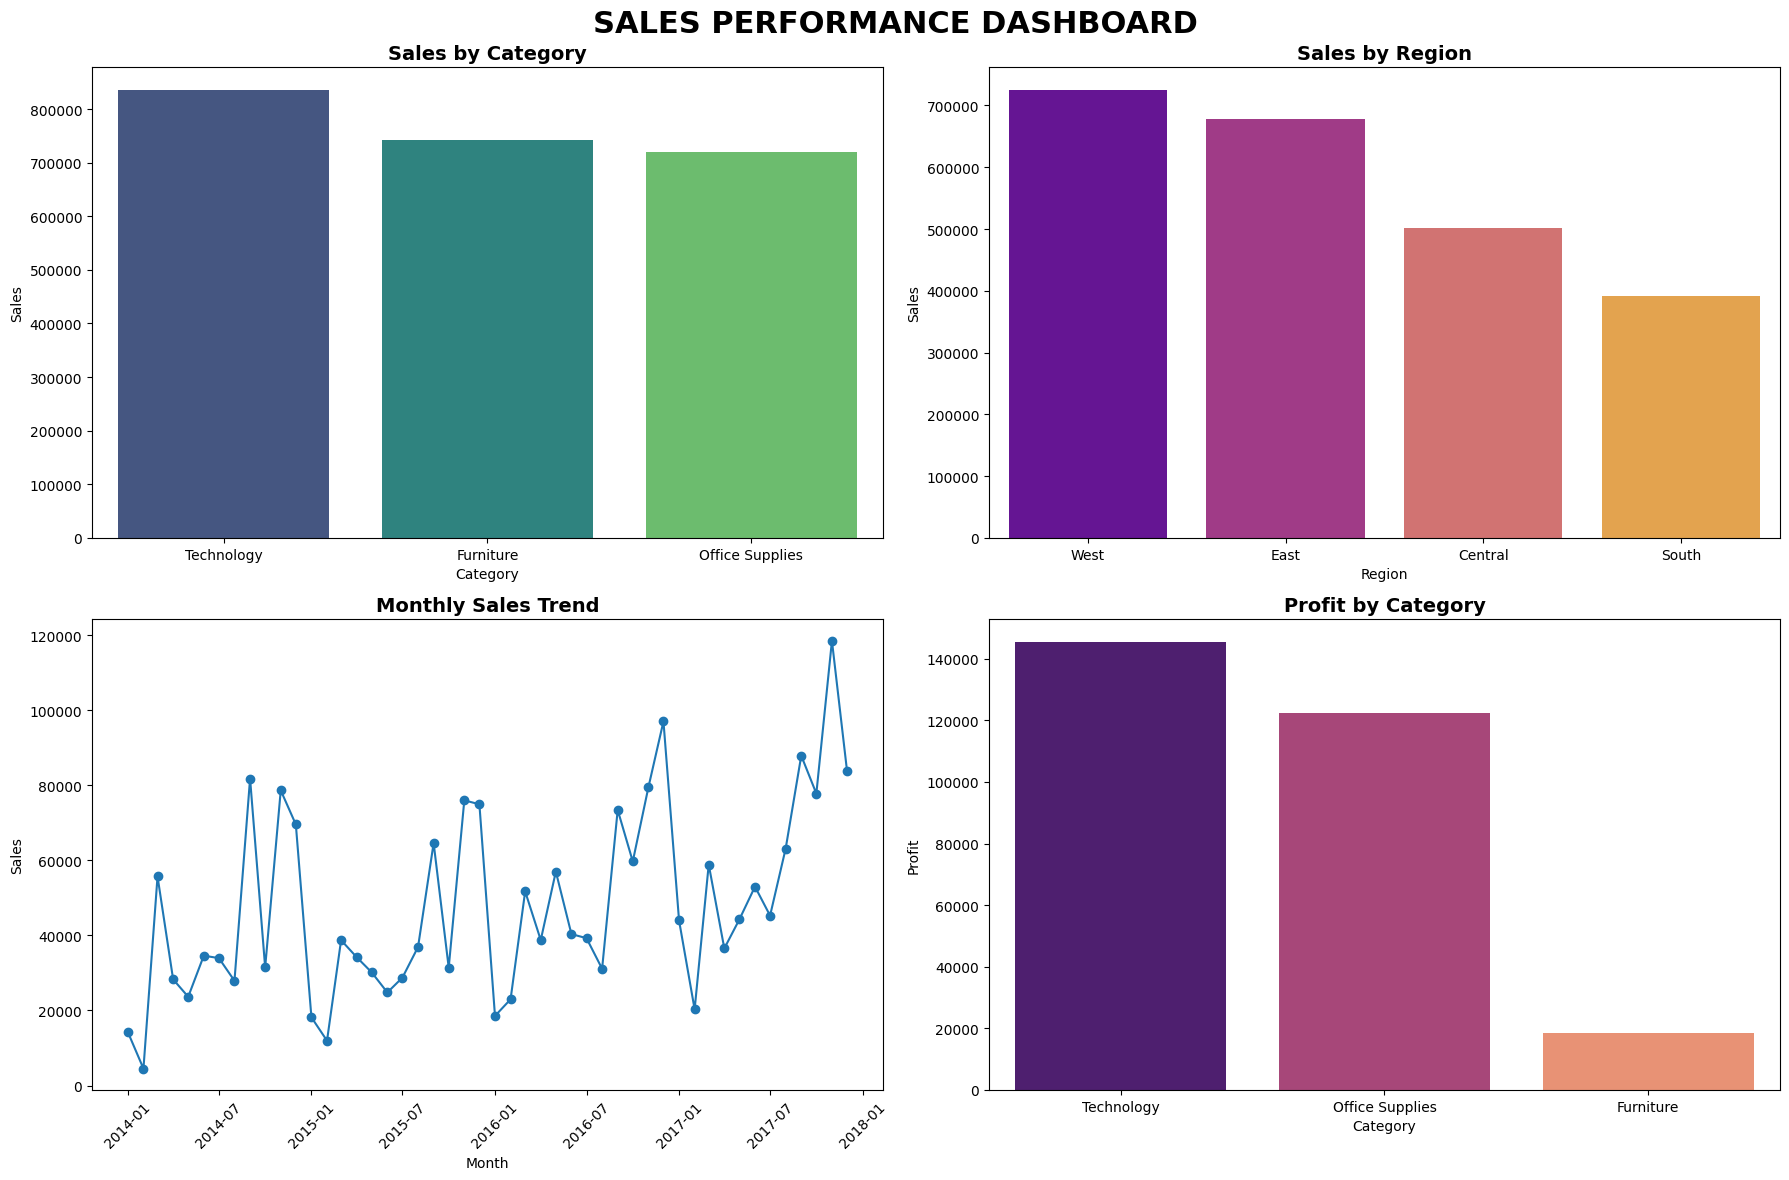

In [45]:
fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(2, 2)

# 1. Sales by Category
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis",
    ax=ax1
)
ax1.set_title("Sales by Category", fontsize=14, fontweight="bold")
ax1.set_xlabel("Category")
ax1.set_ylabel("Sales")

# 2. Sales by Region
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="plasma",
    ax=ax2
)
ax2.set_title("Sales by Region", fontsize=14, fontweight="bold")
ax2.set_xlabel("Region")
ax2.set_ylabel("Sales")

# 3. Monthly Sales Trend
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
ax3.set_title("Monthly Sales Trend", fontsize=14, fontweight="bold")
ax3.set_xlabel("Month")
ax3.set_ylabel("Sales")
ax3.tick_params(axis="x", rotation=45)

# 4. Profit by Category
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    palette="magma",
    ax=ax4
)
ax4.set_title("Profit by Category", fontsize=14, fontweight="bold")
ax4.set_xlabel("Category")
ax4.set_ylabel("Profit")

fig.suptitle(
    "SALES PERFORMANCE DASHBOARD",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [46]:
print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print("1. Highest Sales Category:", category_sales.idxmax())
print("2. Highest Sales Region:", region_sales.idxmax())
print("3. Most Profitable Category:", category_profit.idxmax())
print("4. Top-Selling Product:", top_products.idxmax())
print("5. Overall Profit Margin:", round(profit_margin, 2), "%")

KEY BUSINESS INSIGHTS
----------------------------------------
1. Highest Sales Category: Technology
2. Highest Sales Region: West
3. Most Profitable Category: Technology
4. Top-Selling Product: Canon imageCLASS 2200 Advanced Copier
5. Overall Profit Margin: 12.47 %


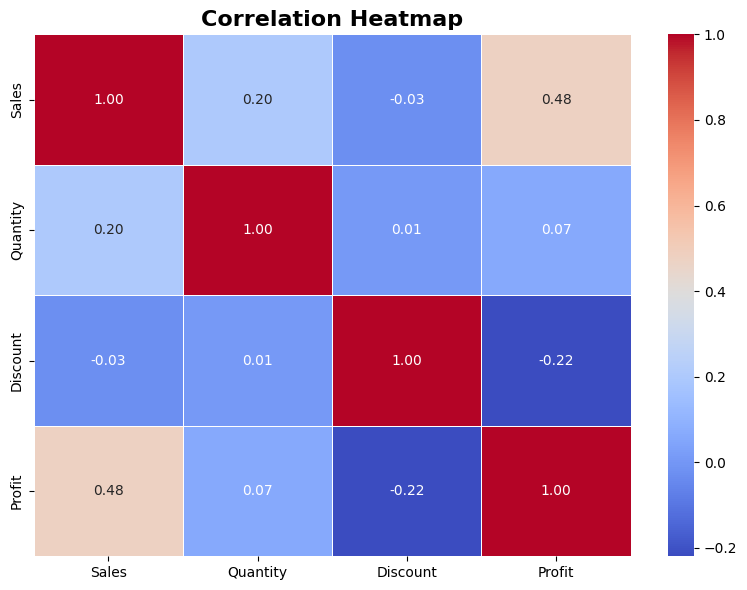

In [47]:
numeric_data = df[['Sales', 'Quantity', 'Discount', 'Profit']]

correlation = numeric_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [49]:
print("FINAL BUSINESS INSIGHTS")
print("=" * 50)

print(f"1. Highest Sales Category: {category_sales.idxmax()}")
print(f"   Sales: {category_sales.max():,.2f}")

print(f"\n2. Highest Sales Region: {region_sales.idxmax()}")
print(f"   Sales: {region_sales.max():,.2f}")

print(f"\n3. Most Profitable Category: {category_profit.idxmax()}")
print(f"   Profit: {category_profit.max():,.2f}")

print(f"\n4. Top-Selling Product: {top_products.idxmax()}")
print(f"   Sales: {top_products.max():,.2f}")

print(f"\n5. Overall Profit Margin: {profit_margin:.2f}%")

print("\n6. Total Sales:", f"{total_sales:,.2f}")
print("7. Total Profit:", f"{total_profit:,.2f}")
print("8. Total Orders:", f"{total_orders:,}")

FINAL BUSINESS INSIGHTS
1. Highest Sales Category: Technology
   Sales: 836,154.03

2. Highest Sales Region: West
   Sales: 725,457.82

3. Most Profitable Category: Technology
   Profit: 145,454.95

4. Top-Selling Product: Canon imageCLASS 2200 Advanced Copier
   Sales: 61,599.82

5. Overall Profit Margin: 12.47%

6. Total Sales: 2,297,200.86
7. Total Profit: 286,397.02
8. Total Orders: 5,009


In [50]:
print("BUSINESS RECOMMENDATIONS")
print("=" * 50)

print(f"1. Focus on the {category_sales.idxmax()} category because it generates the highest sales.")

print(f"2. Strengthen sales strategies in the {region_sales.idxmax()} region, which has the highest sales.")

print(f"3. Prioritize the most profitable category: {category_profit.idxmax()}.")

print(f"4. Promote and maintain inventory for the top-selling product: {top_products.idxmax()}.")

print("5. Monitor discount levels carefully to protect overall profitability.")

print("6. Use monthly sales trends to plan inventory and marketing campaigns.")

BUSINESS RECOMMENDATIONS
1. Focus on the Technology category because it generates the highest sales.
2. Strengthen sales strategies in the West region, which has the highest sales.
3. Prioritize the most profitable category: Technology.
4. Promote and maintain inventory for the top-selling product: Canon imageCLASS 2200 Advanced Copier.
5. Monitor discount levels carefully to protect overall profitability.
6. Use monthly sales trends to plan inventory and marketing campaigns.


/tmp/ipykernel_1848/2833126416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


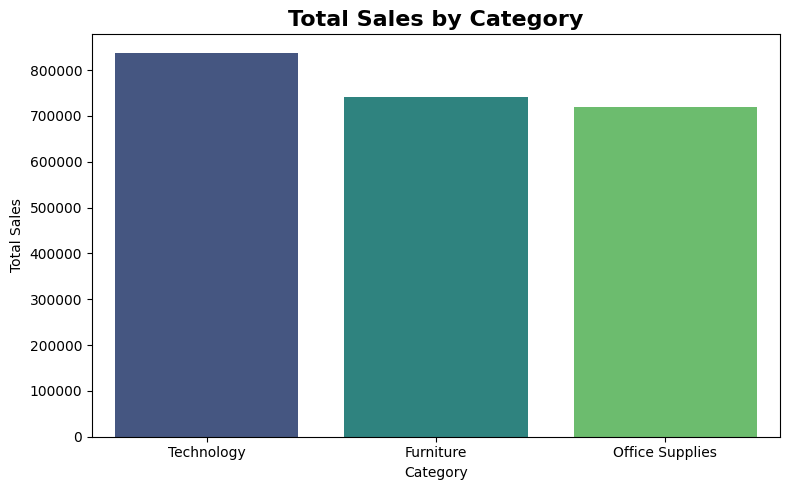

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1848/2086172134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


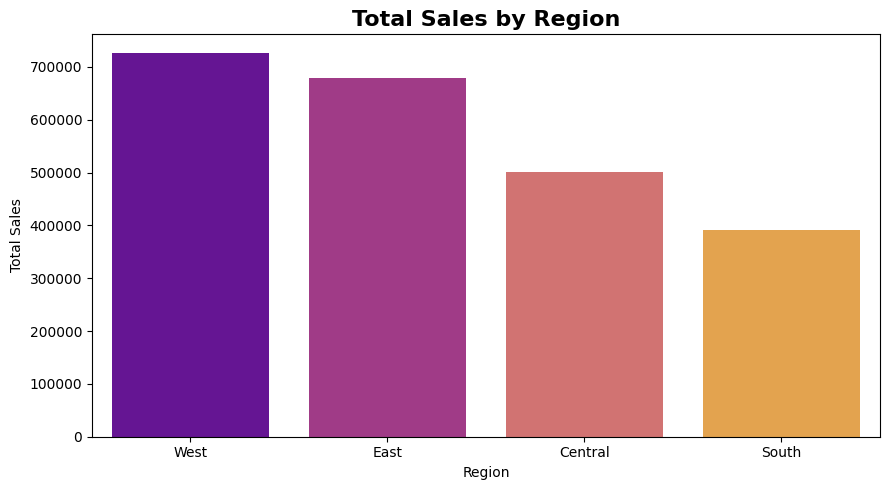

In [52]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="plasma"
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig("sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

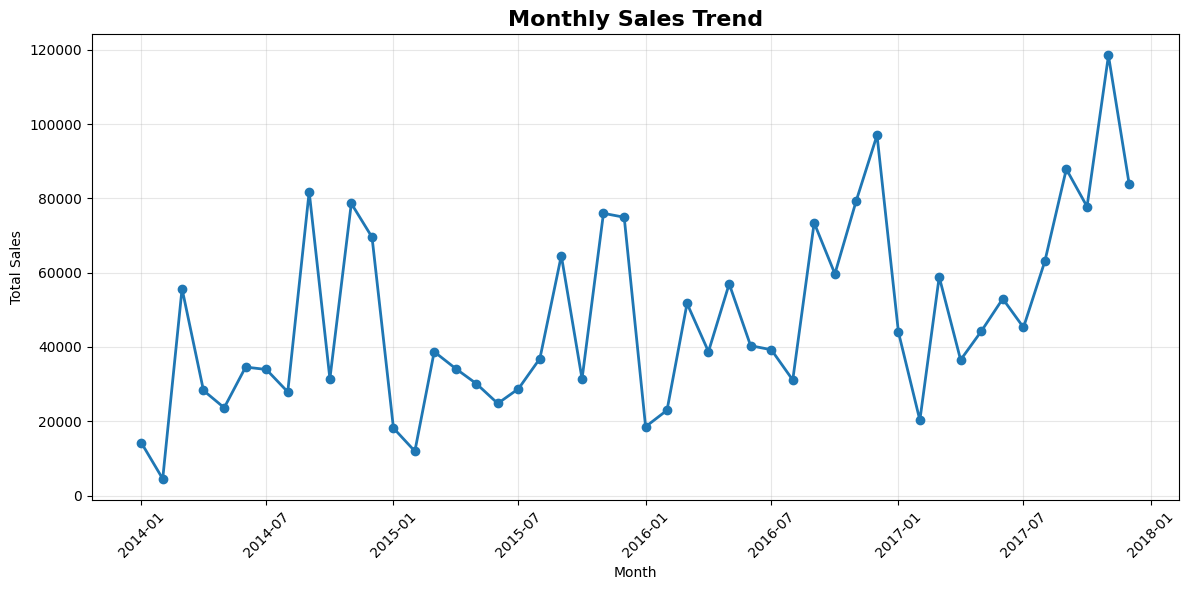

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1848/92696810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


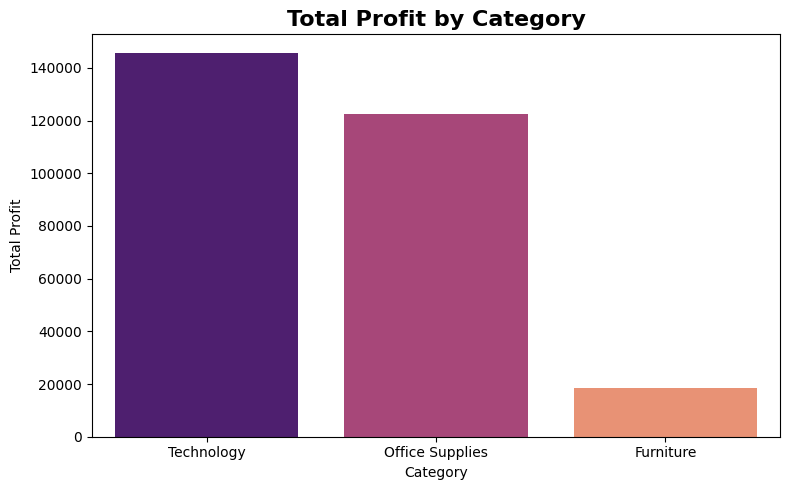

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    palette="magma"
)

plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()

plt.savefig("profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
import os

files = [
    "sales_by_category.png",
    "sales_by_region.png",
    "monthly_sales_trend.png",
    "profit_by_category.png"
]

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

✅ sales_by_category.png
✅ sales_by_region.png
✅ monthly_sales_trend.png
✅ profit_by_category.png


In [56]:
import os

os.makedirs("Task_3_Data_Visualization/visualizations", exist_ok=True)

print("Project folder created successfully!")

Project folder created successfully!


In [57]:
import shutil

files = [
    "sales_by_category.png",
    "sales_by_region.png",
    "monthly_sales_trend.png",
    "profit_by_category.png"
]

for file in files:
    shutil.move(
        file,
        "Task_3_Data_Visualization/visualizations/" + file
    )

print("All visualizations moved successfully!")

All visualizations moved successfully!
